# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load Dataset

In [ ]:
df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [ ]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Insight

This dataset contains labelled network traffic from the CICIDS2017 intrusion detection dataset. It is suitable for analysing AI-based cyber threat detection because it includes both benign and DDoS attack traffic.

# Check Dataset Shape

In [ ]:
print("Rows and columns:", df.shape)

Rows and columns: (225745, 79)


### Insight

The dataset contains a large number of network traffic records and features, making it appropriate for machine learning-based intrusion detection analysis.

# Check Columns

In [ ]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

# Clean Column Names

In [ ]:
df.columns = df.columns.str.strip()

df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

### Insight

Cleaning column names helps prevent errors during analysis because some CICIDS2017 columns contain unnecessary spaces.

# Check Missing Values

In [ ]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


### Insight

Checking missing values is important because incomplete network traffic records may affect the reliability of the machine learning model.

# Check Label Distribution

In [ ]:
df["Label"].value_counts()

,count
Label,
DDoS,128027
BENIGN,97718


### Insight

The label distribution shows the number of benign and DDoS traffic records. This helps identify whether the dataset is balanced or imbalanced before model training.

# Visualise Label Distribution

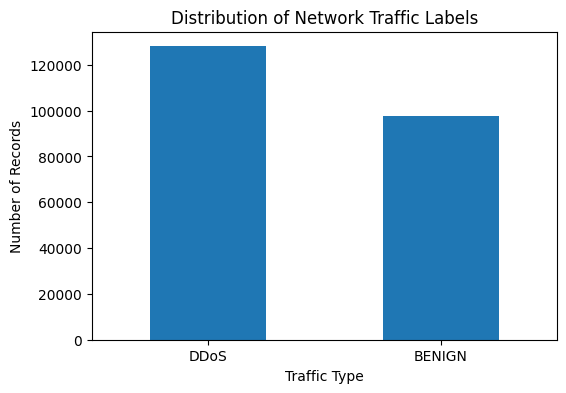

In [ ]:
df["Label"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Distribution of Network Traffic Labels")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

### Insight

The chart shows the proportion of normal and attack traffic in the dataset. This supports the research focus on distinguishing malicious DDoS activity from benign network behaviour.

# Replace Infinite Values

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop Missing Values

In [ ]:
df.dropna(inplace=True)

print("Rows and columns after cleaning:", df.shape)

Rows and columns after cleaning: (225711, 79)


### Insight

Removing missing and infinite values improves data quality and ensures that the machine learning model receives valid numerical inputs.

# Encode Target Label

In [ ]:
le = LabelEncoder()

df["Label_Encoded"] = le.fit_transform(df["Label"])

df[["Label", "Label_Encoded"]].head()

,Label,Label_Encoded
0,BENIGN,0
1,BENIGN,0
2,BENIGN,0
3,BENIGN,0
4,BENIGN,0


### Insight

The target label is converted into numerical form so it can be used by the machine learning algorithm. This allows the model to classify traffic as either benign or DDoS.

# Separate Features and Target

In [ ]:
X = df.drop(columns=["Label", "Label_Encoded"])
y = df["Label_Encoded"]

# Keep Only Numeric Features

In [ ]:
X = X.select_dtypes(include=[np.number])

X.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


### Insight

Only numerical features are selected because machine learning models such as Random Forest require numerical input values for training and prediction.

# Correlation Heatmap

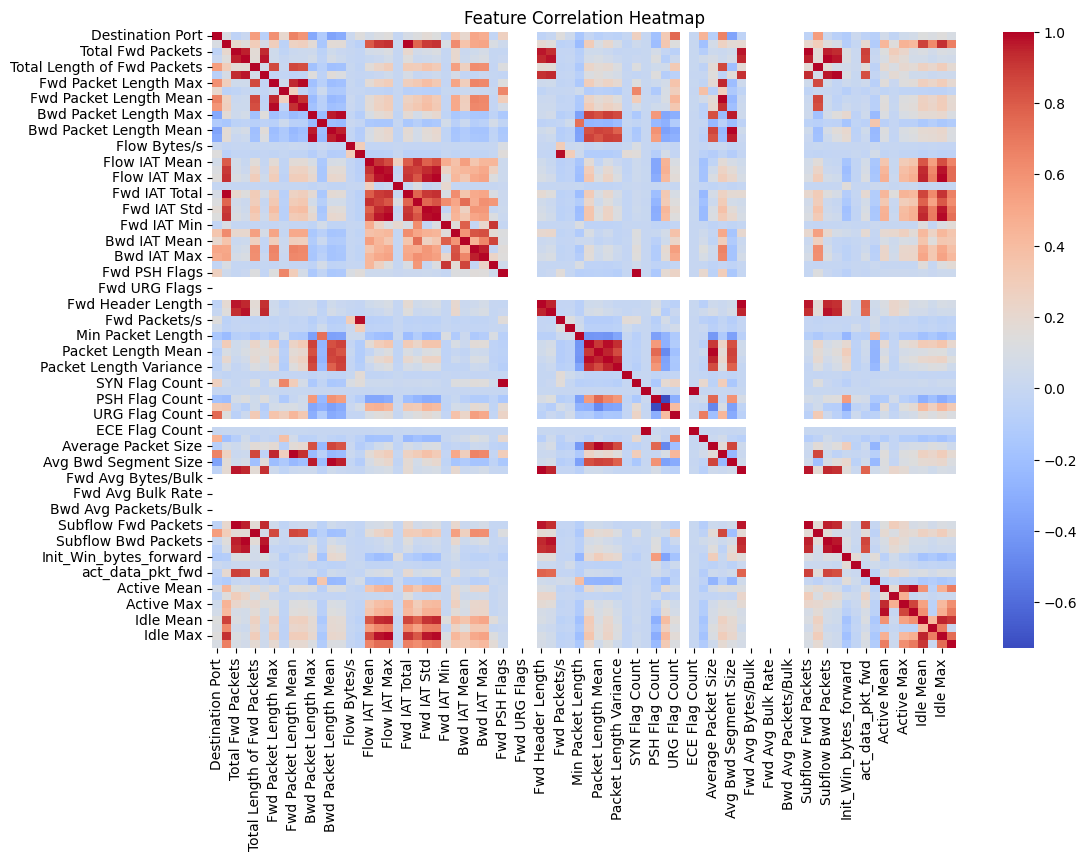

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Insight

The heatmap identifies relationships between network traffic features. Strong correlations may indicate redundant variables, while weak correlations suggest independent behavioural indicators useful for cyber threat detection.

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (180568, 78)
Testing set: (45143, 78)


### Insight

The dataset is divided into training and testing sets to evaluate how well the model performs on unseen network traffic data.

# Train Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

### Insight

Random Forest is used because it is effective for classification problems and can handle many network traffic features. It is also commonly used in intrusion detection research due to its strong accuracy and interpretability.

# Make Predictions

In [ ]:
y_pred = rf_model.predict(X_test)

# Accuracy Score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.9998892408568327


### Insight

The accuracy score shows the overall percentage of correctly classified network traffic records. A high accuracy indicates that the model can effectively distinguish between benign and DDoS traffic.

# ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9999996981632876


### Insight

The ROC-AUC score evaluates how effectively the model distinguishes between benign and malicious traffic across different classification thresholds. A high ROC-AUC indicates strong detection capability.

# Classification Report

In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



### Insight

The classification report provides precision, recall, and F1-score. These metrics are important because they show how well the model detects DDoS attacks, not just how accurate it is overall.

# Precision-Recall Curve

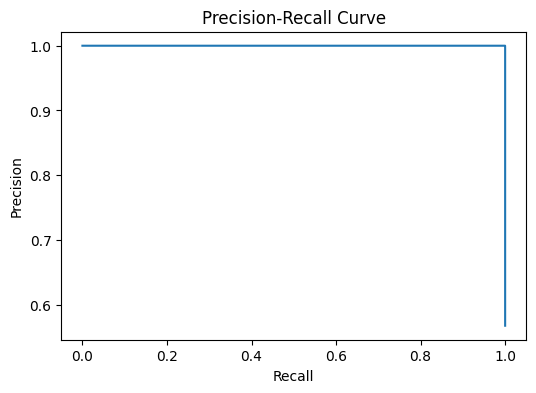

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(recall, precision)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

### Insight

The precision-recall curve evaluates the balance between correctly detecting attacks and minimizing false alarms. This is especially important in cybersecurity where missed attacks can have severe consequences.

# Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[19536     2]
 [    3 25602]]


# Confusion Matrix Chart

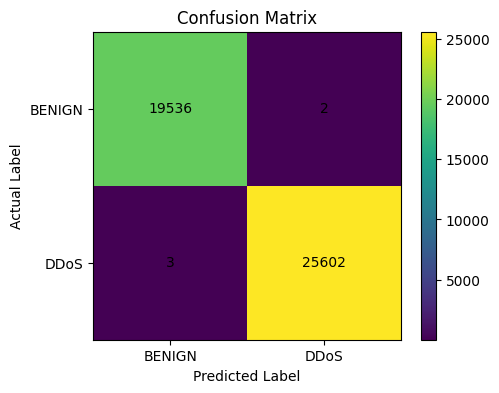

In [ ]:
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0,1], le.classes_)
plt.yticks([0,1], le.classes_)

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

### Insight

The confusion matrix shows how many benign and DDoS records were correctly and incorrectly classified. This is useful for evaluating whether the model is reliable for cyber threat detection.

# ROC Curve

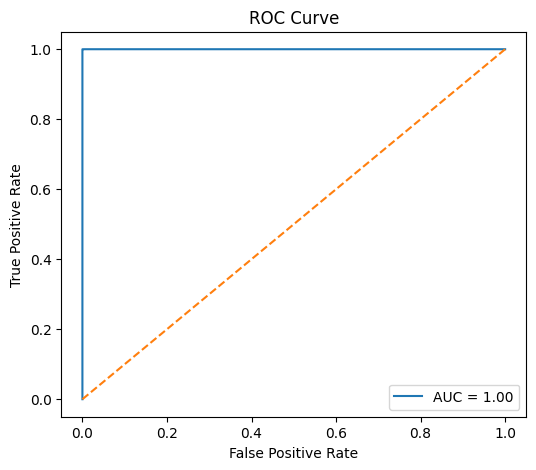

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Insight

The ROC curve demonstrates the Random Forest model’s strong ability to distinguish between benign and malicious network traffic across multiple classification thresholds. The high AUC value indicates reliable classification performance and supports the effectiveness of AI-based intrusion detection techniques.

# Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
53,Avg Fwd Segment Size,0.077440
66,Init_Win_bytes_forward,0.075562
6,Fwd Packet Length Max,0.073598
8,Fwd Packet Length Mean,0.073032
62,Subflow Fwd Packets,0.056864
63,Subflow Fwd Bytes,0.056328
4,Total Length of Fwd Packets,0.049570
11,Bwd Packet Length Min,0.047531
0,Destination Port,0.045286
68,act_data_pkt_fwd,0.039401


### Insight

Feature importance identifies which network traffic characteristics contributed most to DDoS detection. This improves interpretability and supports the research discussion on AI-based IDS decision-making.

# Feature Importance Chart

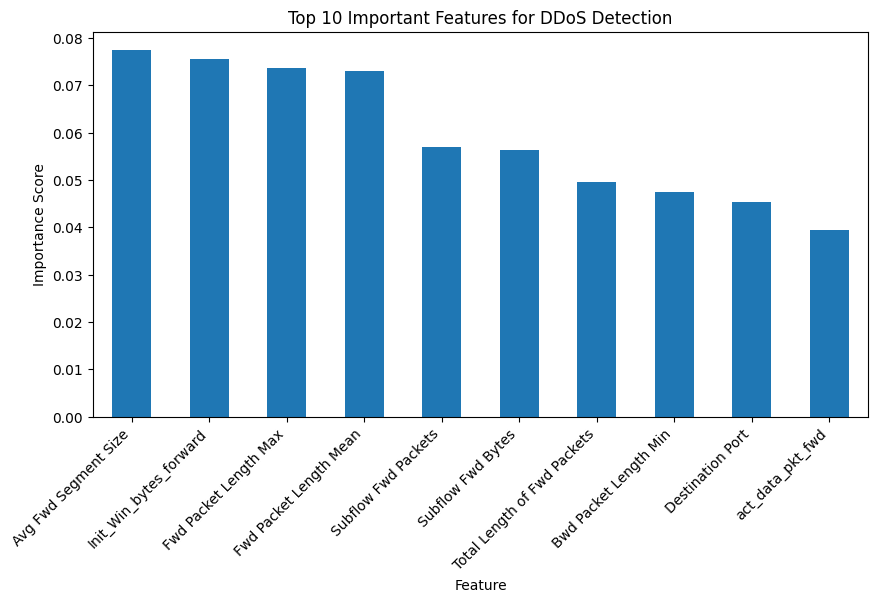

In [ ]:
top_features = feature_importance.head(10)

top_features.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 10 Important Features for DDoS Detection")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.show()

### Insight

The most important features help explain which traffic patterns are most useful for detecting DDoS attacks. This supports the idea that AI-based IDS can identify suspicious network behaviour through data-driven analysis.

# Final Notebook Conclusion

In [ ]:
print("""
The Random Forest model was able to classify benign and DDoS network traffic using the CICIDS2017 dataset.
The results support the research argument that AI-based Intrusion Detection Systems can improve cyber threat detection.
However, this dataset is a benchmark IDS dataset and does not represent real hospital network traffic directly.
Therefore, the findings should be interpreted as supportive experimental evidence for AI-based IDS, rather than a full hospital-specific deployment.
""")


The Random Forest model was able to classify benign and DDoS network traffic using the CICIDS2017 dataset.
The results support the research argument that AI-based Intrusion Detection Systems can improve cyber threat detection.
However, this dataset is a benchmark IDS dataset and does not represent real hospital network traffic directly.
Therefore, the findings should be interpreted as supportive experimental evidence for AI-based IDS, rather than a full hospital-specific deployment.



### Insight

The notebook demonstrates that machine learning can be applied to detect cyber threats using labelled network traffic data. This supports the research paper’s argument that AI-based IDS can strengthen cybersecurity detection, while also acknowledging that further testing using real hospital or healthcare-specific data would improve practical validity.

# Reflection Section

In [ ]:
print("""
Reflection:
The notebook demonstrated that AI-based machine learning models can effectively classify network traffic and detect DDoS attacks.
However, the study also revealed limitations related to dataset generalizability, computational requirements, and dependence on benchmark datasets rather than real hospital traffic.
Future improvements may include using healthcare-specific intrusion datasets, explainable AI models, and real-time IDS deployment testing.
""")


Reflection:
The notebook demonstrated that AI-based machine learning models can effectively classify network traffic and detect DDoS attacks.
However, the study also revealed limitations related to dataset generalizability, computational requirements, and dependence on benchmark datasets rather than real hospital traffic.
Future improvements may include using healthcare-specific intrusion datasets, explainable AI models, and real-time IDS deployment testing.



### Insight

The reflection highlights both the strengths and limitations of the AI-based IDS approach. This demonstrates critical awareness of methodological constraints and supports future research considerations in healthcare cybersecurity.